# **XAI4Spectra**

# **Loading data**

In [2]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks

# loading a soil spectral dataset based on X-ray fluorescence (XRF)
data_complete = pd.read_csv('XRF_databases/soil/plsda/soil.csv', sep=';') # local copy of Toledo 2022 dataset
data = data_complete.loc[:, '1':'15']

## **PLS- (R or DA) modeling**

# **Classification case**

In [3]:
data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.loc[:, '1':'15'], test_size=0.30) # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.loc[:, '1':'15'], test_size=0.30) # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True) # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0]) # creating the target variable for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0]) # creating the target variable for prediction set

# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

Xcalclass_prep, mean_calclass, mean_calclass_poisson  = prepr.poisson(Xcalclass, mc=True)
Xpredclass_prep = ((Xpredclass/np.sqrt(mean_calclass)) - mean_calclass_poisson)


C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-12-16 07:35:38,976 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-12-16 07:35:38,990 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

In [4]:
pd.options.plotting.backend = 'plotly' # setting plotly as the backend for pandas plotting 
Xcalclass.T.plot() # easily plotting the spectra 

In [5]:
from modeling import pls_optimized

# performing PLS-DA with optimized latent variables
plsda_results = pls_optimized(Xcalclass_prep, 
                              ycalclass,
                              LVmax=4,
                              Xpred=Xpredclass_prep,
                              ypred=ypredclass,
                              aim='classification',
                              cv=10)
plsda_results[0]

,LVs,Accuracy Cal,Sensitivity Cal,Specificity Cal,CM Cal,Accuracy CV,Sensitivity CV,Specificity CV,CM CV,Accuracy Pred,Sensitivity Pred,Specificity Pred,CM Pred,X Cum Exp Var,Y Cum Exp Var,X Ind Exp Var,Y Ind Exp Var
0,1,0.804054,0.845070,0.766234,"[[59, 18], [11, 60]]",0.722973,0.746479,0.701299,"[[54, 23], [18, 53]]",0.750000,0.870968,0.636364,"[[21, 12], [4, 27]]",24.084452,18.486320,24.084452,18.486320
1,2,0.851351,0.915493,0.792208,"[[61, 16], [6, 65]]",0.810811,0.873239,0.753247,"[[58, 19], [9, 62]]",0.843750,0.967742,0.727273,"[[24, 9], [1, 30]]",46.025807,20.883518,21.941354,2.397198
2,3,0.831081,0.901408,0.766234,"[[59, 18], [7, 64]]",0.797297,0.845070,0.753247,"[[58, 19], [11, 60]]",0.828125,0.967742,0.696970,"[[23, 10], [1, 30]]",70.291459,21.960174,24.265653,1.076656
3,4,0.871622,0.887324,0.857143,"[[66, 11], [8, 63]]",0.770270,0.845070,0.701299,"[[54, 23], [11, 60]]",0.875000,0.967742,0.787879,"[[26, 7], [1, 30]]",78.655943,24.395837,8.364483,2.435663


In [6]:
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_cuts = [
('background1', 1.0, 1.33),
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('P', 1.87, 2.10),
('background2', 2.11, 2.19),
('S', 2.20, 2.44),
('background3', 2.45, 2.55),
('Rh L + Ar', 2.56, 3.10),
('background4', 3.11, 3.21),
('K', 3.22, 3.42),
('background5', 3.43, 3.53),
('Ca ka', 3.54, 3.84),
('Ca kb', 3.92, 4.14),
('background6', 4.15, 4.37),
('Ti ka', 4.38, 4.66),
('background7', 4.67, 4.75),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.02),
('background8', 6.03, 6.13),
('Fe ka', 6.14, 6.68),
('background9', 6.69, 6.80),
('Fe kb', 6.81, 7.30),
('background10', 7.31, 7.91),
('Cu', 7.92, 8.20),
('background11', 8.21, 10.69),
('Fe ka + Ti ka', 10.7, 11.14),
('background12', 11.15, 12.55),
('sum Fe' , 12.56, 13.1),
('background13', 13.11, 15.0)
]

In [7]:
def extract_spectral_zones(Xcal, cuts):
    """
    Extract spectral zones from a DataFrame based on specified cuts.
    
    Parameters
    ----------
    - **Xcal** : pd.DataFrame
        DataFrame with spectral data, where columns are wavelengths/energies.
    - **cuts** : list of tuples/lists or dicts
        Each item defines a spectral zone to extract.
        - If tuple/list: (start, end) or (name, start, end)
        - If dict: {'name': str, 'start': float, 'end': float}
    
    Returns
    -------
    - **zones** : dict
        Dictionary where keys are zone names and values are DataFrames with the extracted spectral zones.
    """
    import numpy as np
    import pandas as pd

    # convert the column names to numeric when possible (NaN when not convertible)
    col_nums = pd.to_numeric(Xcal.columns.astype(str), errors='coerce')
    zones = {} # dictionary to store extracted zones

    for cut in cuts:
        # normalize cut format
        if isinstance(cut, dict): # if dict
            name = cut.get('name', f"{cut.get('start')}-{cut.get('end')}") # default name if not provided
            start = cut.get('start') # getting start value
            end = cut.get('end') # getting end value
        elif isinstance(cut, (list, tuple)): # if list/tuple
            if len(cut) == 2: 
                start, end = cut # getting start and end values
                name = f"{start}-{end}" # default name
            elif len(cut) == 3: # if name provided
                name, start, end = cut # getting name, start and end values
            else:
                raise ValueError("Cuts in tuple/list format must have 2 or 3 elements.")
        else:
            raise ValueError("Each cut must be a dict or a tuple/list.")

        # validate start and end
        try:
            s = float(start)
            e = float(end)
        except Exception: # Exception for conversion errors
            raise ValueError("star and end must be numeric values (int/float or convertible strings).")

        if s > e: # swap if necessary
            s, e = e, s

        # to select columns whose numeric value is in the interval [s, e]
        mask = (~np.isnan(col_nums)) & (col_nums >= s) & (col_nums <= e)
        selected_cols = list(Xcal.columns[mask])

        # piecing the zone DataFrame into the dictionary
        zones[name] = Xcal.loc[:, selected_cols]

    return zones


spectral_zones_class = extract_spectral_zones(Xcalclass, spectral_cuts) # extracting the spectral zones
spectral_zones_class['Fe ka + Ti ka'].T.plot(title='spectral zone') # plotting the Al ka spectral zone

# **Extracting predicates - plsda case**

In [8]:
def aggregate_spectral_zones(spectral_zones_dict, aggregator='sum'):
    """
    Agrega os valores das zonas espectrais usando diferentes funções de agregação.
    
    Esta função processa cada zona espectral (DataFrame com múltiplas colunas de energia)
    e reduz cada linha (amostra) a um único valor numérico usando a função de agregação
    especificada.
    
    Parameters
    ----------
    - **spectral_zones_dict** : dict
        Dicionário retornado por extract_spectral_zones, onde:
        - chaves = nomes das zonas espectrais (ex: 'Ca ka', 'Fe ka')
        - valores = DataFrames com dados espectrais (linhas=amostras, colunas=energias)
    
    - **aggregator** : str, opcional (padrão='sum')
        Função de agregação a aplicar nas colunas de cada zona. Opções:
        - **'sum'**: Soma de todos os valores da zona (padrão)
        - **'mean'**: Média aritmética dos valores
        - **'median'**: Mediana dos valores
        - **'max'**: Valor máximo na zona
        - **'std'**: Desvio padrão dos valores
        - **'var'**: Variância dos valores
    
    Returns
    -------
    - **aggregated_df** : pd.DataFrame
        DataFrame com valores agregados, onde:
        - linhas = amostras (mesmo índice dos DataFrames originais)
        - colunas = zonas espectrais
        - valores = resultado da agregação (mesmo formato que .sum(axis=1))
    
    Raises
    ------
    - ValueError
        Se o agregador especificado não for reconhecido.
    """
    import pandas as pd
    import numpy as np
    
    # VALIDAÇÃO DE ENTRADA
    valid_aggregators = ['sum', 'mean', 'median', 'max', 'min', 'std', 'var']
    
    if aggregator not in valid_aggregators:
        raise ValueError(
            f"Agregador '{aggregator}' não reconhecido.\n"
            f"Opções válidas: {', '.join(valid_aggregators)}"
        )
    
    # MAPEAMENTO DOS AGREGADORES
    # Dicionário que mapeia strings para funções do pandas
    aggregation_functions = {
        'sum': lambda df: df.sum(axis=1),        # soma ao longo das colunas
        'mean': lambda df: df.mean(axis=1),      # média
        'median': lambda df: df.median(axis=1),  # mediana
        'max': lambda df: df.max(axis=1),        # valor máximo
        'min': lambda df: df.min(axis=1),        # valor mínimo
        'std': lambda df: df.std(axis=1),        # desvio padrão
        'var': lambda df: df.var(axis=1),        # variância
    }
    
    # AGREGAÇÃO DAS ZONAS ESPECTRAIS
    aggregated_dict = {}  # dicionário para armazenar resultados
    
    for zone_name, zone_df in spectral_zones_dict.items():
        # Aplica a função de agregação selecionada
        # O resultado é uma Series (mesma estrutura que .sum(axis=1))
        aggregated_series = aggregation_functions[aggregator](zone_df)
        
        # Armazena no dicionário
        aggregated_dict[zone_name] = aggregated_series
    
    # CONSTRUÇÃO DO DATAFRAME FINAL
    # Cada chave vira uma coluna, preservando os índices originais
    aggregated_df = pd.DataFrame(aggregated_dict)    
    return aggregated_df

zone_sums_df = aggregate_spectral_zones(spectral_zones_class, aggregator='sum')
zone_sums_df

,background1,Al,Si,P,background2,S,background3,Rh L + Ar,background4,K,...,Fe ka,background9,Fe kb,background10,Cu,background11,Fe ka + Ti ka,background12,sum Fe,background13
0,2.365,27.140,88.340,4.835,0.985,7.065,2.290,149.635,6.045,17.040,...,4206.615,13.885,672.985,26.115,17.270,87.905,17.665,33.740,31.570,18.855
1,2.355,31.650,83.060,5.040,1.025,7.100,2.350,153.020,6.075,18.040,...,4000.315,13.815,639.965,28.305,17.100,94.485,17.800,35.475,29.650,18.750
2,2.320,28.905,88.685,4.065,0.990,6.240,2.390,151.535,6.220,13.980,...,4223.315,14.140,674.000,26.730,17.140,90.535,17.815,33.840,31.545,18.785
3,2.275,30.260,81.205,4.460,1.025,7.115,2.420,152.310,6.010,13.790,...,4392.400,14.695,702.445,26.465,16.830,89.225,18.615,34.730,32.830,19.555
4,2.330,32.650,93.030,4.275,0.915,6.500,2.330,154.015,6.155,15.965,...,4222.200,14.150,674.620,27.835,17.420,92.255,18.450,34.600,31.270,19.275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,2.355,32.800,78.740,4.610,0.975,7.085,2.405,149.690,6.165,13.920,...,4632.705,15.485,734.765,28.650,17.155,93.010,17.125,34.545,36.385,21.280
144,2.200,30.960,78.520,6.260,1.100,6.980,2.600,151.950,6.250,15.140,...,4329.930,14.100,691.060,27.910,16.990,95.340,19.810,36.120,34.280,20.380
145,2.290,32.770,76.400,4.110,0.870,6.390,2.380,153.370,6.450,14.160,...,4411.650,15.010,702.360,27.520,16.810,94.170,19.250,36.280,34.640,20.290
146,2.260,28.300,67.545,4.030,0.905,6.340,2.165,145.455,5.580,13.730,...,3923.505,13.420,631.615,25.930,15.935,88.780,16.610,33.285,28.185,18.020


In [9]:
def predicates_by_quantiles(zone_sums_df, quantiles):
    """
    Generate predicates based on specified quantiles for each column in a DataFrame
    and create a predicate indicator matrix.
    
    Parameters
    ----------
    - **zone_sums_df** : pd.DataFrame
        DataFrame with summed values for spectral zones.
    - **quantiles** : list of float
        List of quantiles (between 0 and 1) to generate predicates for.
    
    Returns
    -------
    - **predicates_df** : pd.DataFrame
        DataFrame containing the generated predicates with columns:
        'predicate', 'rule', 'zone', 'thresholds', 'operator'.
    - **predicate_indicator_df** : pd.DataFrame
        Binary indicator matrix (samples × predicates) where 1 indicates
        the sample satisfies the predicate, 0 otherwise.
    """
    import pandas as pd
    import numpy as np

    # calculating the quantiles for each column of zone_sums_df
    zone_quantiles = zone_sums_df.quantile(quantiles)
    
    zone_predicate_list = []
    predicate_num = 1
    for zone in zone_sums_df.columns:
        for q in quantiles:
            q_value = zone_quantiles.loc[q, zone]
            # <= Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} <= {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': "<="
            })
            predicate_num += 1
            # > Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} > {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': ">"
            })
            predicate_num += 1
    
    predicates_df = pd.DataFrame(zone_predicate_list)
    
    # Generating the predicate indicator DataFrame
    
    # function to evaluate a predicate for a given value
    def eval_predicate(value, thresholds, operator):
        if operator == "<=":
            return float(value <= float(thresholds))
        elif operator == ">":
            return float(value > float(thresholds))
        else:
            return np.nan
    
    # initializing empty DataFrame
    predicate_indicator_df = pd.DataFrame(index=zone_sums_df.index)
    
    # iterating over each predicate
    for _, row in predicates_df.iterrows():
        pred = row['predicate']
        zone = row['zone']
        thresholds = row['thresholds']
        operator = row['operator']
        predicate_indicator_df[pred] = zone_sums_df[zone].apply(
            lambda v: eval_predicate(v, thresholds, operator)
        ).astype(int)
    
    # setting column names to rules for better readability
    predicate_indicator_df.columns = predicates_df['rule'].tolist()
    
    # computing co-occurrence matrix
    co_occurrence_matrix = np.dot(predicate_indicator_df.T, predicate_indicator_df)
    co_occurrence_matrix_df = pd.DataFrame(co_occurrence_matrix, index=predicate_indicator_df.columns, columns=predicate_indicator_df.columns) 

    return predicates_df, predicate_indicator_df, co_occurrence_matrix_df

predicates_quantiles = predicates_by_quantiles(zone_sums_df, [0.25, 0.5, 0.75]) # getting predicates for quartiles
predicates_quantiles[0]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3300\1074515645.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3300\1074515645.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3300\1074515645.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

,predicate,rule,zone,thresholds,operator
0,P1,background1 <= 2.24,background1,2.24,<=
1,P2,background1 > 2.24,background1,2.24,>
2,P3,background1 <= 2.31,background1,2.31,<=
3,P4,background1 > 2.31,background1,2.31,>
4,P5,background1 <= 2.34,background1,2.34,<=
...,...,...,...,...,...
175,P176,background13 > 19.19,background13,19.19,>
176,P177,background13 <= 19.78,background13,19.78,<=
177,P178,background13 > 19.78,background13,19.78,>
178,P179,background13 <= 20.32,background13,20.32,<=


In [10]:
predicates_quantiles[1] # predicate indicator DataFrame

,background1 <= 2.24,background1 > 2.24,background1 <= 2.31,background1 > 2.31,background1 <= 2.34,background1 > 2.34,Al <= 31.35,Al > 31.35,Al <= 32.86,Al > 32.86,...,sum Fe <= 32.69,sum Fe > 32.69,sum Fe <= 33.90,sum Fe > 33.90,background13 <= 19.19,background13 > 19.19,background13 <= 19.78,background13 > 19.78,background13 <= 20.32,background13 > 20.32
0,0,1,0,1,0,1,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0
1,0,1,0,1,0,1,0,1,1,0,...,1,0,1,0,1,0,1,0,1,0
2,0,1,0,1,1,0,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0
3,0,1,1,0,1,0,1,0,1,0,...,0,1,1,0,0,1,1,0,1,0
4,0,1,0,1,1,0,0,1,1,0,...,1,0,1,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,0,1,0,1,0,1,0,1,1,0,...,0,1,0,1,0,1,0,1,0,1
144,1,0,1,0,1,0,1,0,1,0,...,0,1,0,1,0,1,0,1,0,1
145,0,1,1,0,1,0,0,1,1,0,...,0,1,0,1,0,1,0,1,1,0
146,0,1,1,0,1,0,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0


In [11]:
# co-ocurrence matrix
co_occurrence_matrix_df=predicates_quantiles[2]
co_occurrence_matrix_df
## the co-occurrence matrix indicates how many samples satisfy each pair of predicates
## for example, if P1 and P2 co-occur in 10 samples, the value at (P1, P2) and (P2, P1) will be 10
## the principal diagonal indicates how many samples satisfy each individual predicate
## while the off-diagonal elements indicate co-occurrence counts

,background1 <= 2.24,background1 > 2.24,background1 <= 2.31,background1 > 2.31,background1 <= 2.34,background1 > 2.34,Al <= 31.35,Al > 31.35,Al <= 32.86,Al > 32.86,...,sum Fe <= 32.69,sum Fe > 32.69,sum Fe <= 33.90,sum Fe > 33.90,background13 <= 19.19,background13 > 19.19,background13 <= 19.78,background13 > 19.78,background13 <= 20.32,background13 > 20.32
background1 <= 2.24,38,0,38,0,38,0,12,26,22,16,...,26,12,30,8,13,25,26,12,32,6
background1 > 2.24,0,110,43,67,67,43,25,85,51,59,...,48,62,81,29,24,86,48,62,79,31
background1 <= 2.31,38,43,81,0,81,0,22,59,43,38,...,46,35,61,20,24,57,46,35,65,16
background1 > 2.31,0,67,0,67,24,43,15,52,30,37,...,28,39,50,17,13,54,28,39,46,21
background1 <= 2.34,38,67,81,24,105,0,26,79,51,54,...,54,51,77,28,29,76,54,51,80,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
background13 > 19.19,25,86,57,54,76,35,14,97,43,68,...,38,73,74,37,0,111,37,74,74,37
background13 <= 19.78,26,48,46,28,54,20,32,42,53,21,...,65,9,73,1,37,37,74,0,74,0
background13 > 19.78,12,62,35,39,51,23,5,69,20,54,...,9,65,38,36,0,74,0,74,37,37
background13 <= 20.32,32,79,65,46,80,31,34,77,65,46,...,72,39,101,10,37,74,74,37,111,0


In [12]:
# inserting the assigned class based on the model predictions to the predicate indicator DataFrame
predicates_quantiles[1].insert(0, 'Class_predicted', plsda_results[1].iloc[:, -1]) # inserting the predicted class from plsda_results
predicates_quantiles[1]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3300\499801049.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



,Class_predicted,background1 <= 2.24,background1 > 2.24,background1 <= 2.31,background1 > 2.31,background1 <= 2.34,background1 > 2.34,Al <= 31.35,Al > 31.35,Al <= 32.86,...,sum Fe <= 32.69,sum Fe > 32.69,sum Fe <= 33.90,sum Fe > 33.90,background13 <= 19.19,background13 > 19.19,background13 <= 19.78,background13 > 19.78,background13 <= 20.32,background13 > 20.32
0,A,0,1,0,1,0,1,1,0,1,...,1,0,1,0,1,0,1,0,1,0
1,A,0,1,0,1,0,1,0,1,1,...,1,0,1,0,1,0,1,0,1,0
2,A,0,1,0,1,1,0,1,0,1,...,1,0,1,0,1,0,1,0,1,0
3,A,0,1,1,0,1,0,1,0,1,...,0,1,1,0,0,1,1,0,1,0
4,A,0,1,0,1,1,0,0,1,1,...,1,0,1,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,A,0,1,0,1,0,1,0,1,1,...,0,1,0,1,0,1,0,1,0,1
144,B,1,0,1,0,1,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1
145,B,0,1,1,0,1,0,0,1,1,...,0,1,0,1,0,1,0,1,1,0
146,B,0,1,1,0,1,0,1,0,1,...,1,0,1,0,1,0,1,0,1,0


In [13]:
def create_predicate_info_dict(predicates_df, predicate_indicator_df, zone_aggregated_df, y_predicted_numeric):
    """
    Cria um dicionário com informações detalhadas sobre cada predicado.
    
    Para cada predicado, armazena:
    - Os valores agregados da zona espectral correspondente (das amostras que satisfazem o predicado)
    - Os valores preditos pelo modelo (das mesmas amostras)
    - Opcionalmente: índices das amostras, classe predita, etc.
    
    Parameters
    ----------
    - **predicates_df** : pd.DataFrame
        DataFrame com predicados gerados por `predicates_by_quantiles()` ou similar.
        Colunas obrigatórias: ['predicate', 'rule', 'zone', 'thresholds', 'operator']
        
    - **predicate_indicator_df** : pd.DataFrame
        Matriz binária de indicadores (samples × predicates) retornada por `predicates_by_quantiles()`.
        Colunas são as regras dos predicados (ex: "Ca ka <= 25.5")
        Valores: 1 = amostra satisfaz o predicado, 0 = não satisfaz
        
    - **zone_aggregated_df** : pd.DataFrame
        DataFrame com valores agregados das zonas espectrais (retornado por `aggregate_spectral_zones()`).
        Linhas = amostras, Colunas = zonas espectrais
        Valores = resultado da agregação (sum, mean, median, std, etc.)
        
    - **y_predicted_numeric** : pd.Series, pd.DataFrame ou np.ndarray
        Valores preditos pelo modelo (contínuos).
        - Para PLS-DA: valores entre 0 e 1 (ex: `plsda_results[5].iloc[:, -1]`)
        - Para PLS-R: valores contínuos da variável resposta
        - Deve ter o mesmo número de linhas que `zone_aggregated_df`
    
    Returns
    -------
    - **predicate_info_dict** : dict
        Dicionário estruturado como:
        {
            'Ca ka <= 25.5': DataFrame({
                'Zone_Aggregated': [valores agregados da zona Ca ka],
                'Predicted_Y': [valores preditos pelo modelo],
                'Sample_Index': [índices originais das amostras]
            }),
            'Fe ka > 10.2': DataFrame({...}),
            ...
        }
        
        - Chaves: Regras dos predicados (strings)
        - Valores: DataFrames com 3 colunas:
            - **Zone_Aggregated**: Valores agregados da zona espectral (pode ser soma, média, mediana, etc.)
            - **Predicted_Y**: Valores preditos pelo modelo para essas amostras
            - **Sample_Index**: Índices originais das amostras (para rastreabilidade)
    
    Raises
    ------
    - ValueError
        Se os DataFrames de entrada tiverem número incompatível de amostras
    - KeyError
        Se alguma coluna obrigatória estiver faltando
    """
    import pandas as pd
    import numpy as np
    
    # VALIDAÇÃO DE ENTRADAS
    
    # Verificar colunas obrigatórias em predicates_df
    required_cols = ['predicate', 'rule', 'zone', 'thresholds', 'operator']
    missing_cols = [col for col in required_cols if col not in predicates_df.columns]
    if missing_cols:
        raise KeyError(f"Colunas faltando em predicates_df: {missing_cols}")
    
    # Converter y_predicted_numeric para Series se necessário
    if isinstance(y_predicted_numeric, pd.DataFrame):
        y_predicted_numeric = y_predicted_numeric.iloc[:, -1]  # última coluna
    elif isinstance(y_predicted_numeric, np.ndarray):
        y_predicted_numeric = pd.Series(y_predicted_numeric)
    
    # Verificar compatibilidade de tamanhos
    n_samples_zones = len(zone_aggregated_df)
    n_samples_predicted = len(y_predicted_numeric)
    n_samples_indicators = len(predicate_indicator_df)
    
    if not (n_samples_zones == n_samples_predicted == n_samples_indicators):
        raise ValueError(
            f"Número incompatível de amostras:\n"
            f"  zone_aggregated_df: {n_samples_zones}\n"
            f"  y_predicted_numeric: {n_samples_predicted}\n"
            f"  predicate_indicator_df: {n_samples_indicators}\n"
            f"Todos devem ter o mesmo número de linhas."
        )
    
    # CONSTRUÇÃO DO DICIONÁRIO DE INFORMAÇÕES
    
    predicate_info_dict = {}  # dicionário para armazenar resultados
    n_predicates_processed = 0  # contador de predicados processados
    n_predicates_empty = 0  # contador de predicados sem amostras
    
    # Iterar sobre cada predicado
    for _, row in predicates_df.iterrows():
        
        pred_rule = row['rule']  # regra do predicado (ex: "Ca ka <= 25.5")
        zone_name = row['zone']  # nome da zona espectral (ex: "Ca ka")
        
        # 1. IDENTIFICAR AMOSTRAS QUE SATISFAZEM O PREDICADO
        # Usar a matriz de indicadores para filtrar amostras
        # predicate_indicator_df tem colunas com as regras dos predicados
        
        if pred_rule not in predicate_indicator_df.columns:
            # Predicado não existe na matriz de indicadores (não deveria acontecer)
            continue
        
        # Máscara booleana: True = amostra satisfaz o predicado
        mask_satisfied = predicate_indicator_df[pred_rule] == 1
        
        # Índices das amostras que satisfazem o predicado
        # Usar np.where() para compatibilidade com todos os tipos de índices
        satisfied_indices = np.where(mask_satisfied)[0].tolist()
        
        # 2. VERIFICAR SE HÁ AMOSTRAS SATISFEITAS
        if not satisfied_indices:  # lista vazia
            n_predicates_empty += 1
            continue  # pula este predicado (não adiciona ao dicionário)
        
        # 3. EXTRAIR VALORES AGREGADOS DA ZONA ESPECTRAL
        # Valores agregados (soma, média, mediana, std, etc.) da zona correspondente
        zone_aggregated_values = zone_aggregated_df.loc[satisfied_indices, zone_name]
        
        # 4. EXTRAIR VALORES PREDITOS PELO MODELO
        predicted_values = y_predicted_numeric.iloc[satisfied_indices]
        
        # 5. CRIAR DATAFRAME COM INFORMAÇÕES DO PREDICADO
        df_predicate_info = pd.DataFrame({
            'Zone_Aggregated': zone_aggregated_values.reset_index(drop=True),  # valores agregados
            'Predicted_Y': predicted_values.reset_index(drop=True),  # valores preditos
            'Sample_Index': satisfied_indices  # índices originais (para rastreabilidade)
        })
        
        # 6. ARMAZENAR NO DICIONÁRIO
        predicate_info_dict[pred_rule] = df_predicate_info
        n_predicates_processed += 1
    
    return predicate_info_dict

# Criar dicionário de informações
predicate_info_dict = create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=plsda_results[5].iloc[:, -1]
)

predicate_info_dict[list(predicate_info_dict.keys())[0]]

,Zone_Aggregated,Predicted_Y,Sample_Index
0,2.220,0.170004,16
1,2.220,0.489468,17
2,2.200,0.515101,24
3,2.200,0.442836,30
4,2.135,-0.301298,40
5,2.000,0.459424,41
6,2.220,0.214063,48
7,2.150,0.280978,49
8,2.120,0.421587,51
9,2.200,0.477393,52


# **Bagging**

In [18]:
def bagging_predicates(zone_sums_df, y_predicted_numeric, predicates_df, 
                          n_bags=50, n_predicates_per_bag=20, n_samples_per_bag=80, 
                          min_samples_per_predicate=5, replace=True, random_seed=42,
                          sample_bagging=True, predicate_bagging=True):
    """
    Realiza bagging de predicados com controle granular sobre amostragem.
    
    Estratégia de Bagging (Configurável):
    =====================================
    1. **Amostragem de Linhas (Amostras):**
       - sample_bagging=True: Sorteia N amostras para cada bag
       - sample_bagging=False: Usa TODAS as amostras em todos os bags
    
    2. **Amostragem de Colunas (Predicados):**
       - predicate_bagging=True: Sorteia M predicados para cada bag
       - predicate_bagging=False: Usa TODOS os predicados em todos os bags
    
    3. **Filtragem e Validação:**
       - Para cada predicado selecionado, filtra as amostras que o satisfazem
       - Descarta predicados com insuficiente cobertura (se sample_bagging=True)
    
    Parâmetros
    ----------
    zone_sums_df : pd.DataFrame
        DataFrame com somas das zonas espectrais (linhas=amostras, colunas=zonas).
        
    y_predicted_numeric : pd.Series ou np.ndarray
        Valores preditos pelo modelo (contínuos, entre 0 e 1 para PLS-DA).
        
    predicates_df : pd.DataFrame
        DataFrame com predicados. Colunas obrigatórias:
        - 'rule': Regra legível (ex: "Ca ka <= 25.5")
        - 'zone': Nome da zona espectral
        - 'thresholds': Valor do threshold
        - 'operator': "<=" ou ">"
        
    n_bags : int, default=50
        Número de bags (iterações) a criar.
        
    n_predicates_per_bag : int, default=20
        Número de predicados a sortear por bag.
        **Ignorado se predicate_bagging=False.**
        
    n_samples_per_bag : int, default=80
        Número de amostras a sortear por bag.
        **Ignorado se sample_bagging=False.**
        
    min_samples_per_predicate : int, default=5
        Mínimo de amostras que devem satisfazer um predicado para ele ser válido.
        **Aplicado apenas se sample_bagging=True.**
        
    replace : bool, default=True
        - True: Bootstrap (amostragem com reposição)
        - False: Subsampling (sem reposição)
        **Aplicado apenas se sample_bagging=True.**
        
    random_seed : int, default=42
        Semente aleatória para reprodutibilidade.
        
    sample_bagging : bool, default=True
        - True: Faz subamostragem das LINHAS (amostras variam entre bags)
        - False: Usa todas as amostras em todos os bags
        
    predicate_bagging : bool, default=True
        - True: Faz subamostragem das COLUNAS (predicados variam entre bags)
        - False: Usa todos os predicados em todos os bags
    
    Returns
    -------
    bags_dict : dict
        Dicionário estruturado como:
        {
            'Bag_1': {
                'Ca ka <= 25.5': DataFrame(['Zone_Sum', 'Predicted_Y', 'Sample_Index']),
                'Fe ka > 10.2': DataFrame([...]),
                ...
            },
            'Bag_2': {...},
            ...
        }
    
    """
    import numpy as np
    import pandas as pd
    
    # INICIALIZAÇÃO
    np.random.seed(random_seed)
    
    n_total_samples = len(zone_sums_df)
    predicate_rules = predicates_df['rule'].tolist()
    bags_dict = {}
    
    # LOOP PRINCIPAL: CRIAÇÃO DOS BAGS
    for bag_num in range(1, n_bags + 1):
        
        # 1. SELEÇÃO DE AMOSTRAS (LINHAS) - Controle via `sample_bagging`
        if sample_bagging:
            # Sorteia N amostras (bootstrap ou subsampling)
            bag_sample_indices = np.random.choice(
                range(n_total_samples),
                size=n_samples_per_bag,
                replace=replace  # True=bootstrap, False=subsampling
            )
        else:
            # Usa TODAS as amostras disponíveis
            bag_sample_indices = np.arange(n_total_samples)
        
        # 2. SELEÇÃO DE PREDICADOS (COLUNAS) - Controle via `predicate_bagging`
        if predicate_bagging:
            # Sorteia M predicados aleatoriamente (sem reposição)
            selected_predicate_rules = np.random.choice(
                predicate_rules,
                size=min(n_predicates_per_bag, len(predicate_rules)),
                replace=False
            )
        else:
            # Usa TODOS os predicados disponíveis
            selected_predicate_rules = predicate_rules
        
        # 3. FILTRAGEM E VALIDAÇÃO DE PREDICADOS
        bag_predicate_dict = {}
        n_discarded = 0
        
        for pred_rule in selected_predicate_rules:
            
            # Recupera metadados do predicado
            pred_row = predicates_df[predicates_df['rule'] == pred_rule].iloc[0]
            zone = pred_row['zone']
            threshold = float(pred_row['thresholds'])
            operator = pred_row['operator']
            
            # Extrai valores da zona para as amostras do bag
            zone_values_bag = zone_sums_df.loc[bag_sample_indices, zone].values
            
            # Aplica a regra do predicado
            if operator == "<=":
                mask_satisfied = zone_values_bag <= threshold
            elif operator == ">":
                mask_satisfied = zone_values_bag > threshold
            else:
                continue  # Operador inválido, pula
            
            # Filtra amostras que satisfazem o predicado
            satisfied_indices_in_bag = bag_sample_indices[mask_satisfied]
            
            # Validação de cobertura mínima (apenas se sample_bagging=True)
            if sample_bagging and len(satisfied_indices_in_bag) < min_samples_per_predicate:
                n_discarded += 1
                continue
            
            # Validação básica (descarta predicados vazios sempre)
            if len(satisfied_indices_in_bag) == 0:
                n_discarded += 1
                continue
            
            # Armazena dados do predicado válido
            df_predicate_info = pd.DataFrame({
                'Zone_Sum': zone_sums_df.loc[satisfied_indices_in_bag, zone].values,
                'Predicted_Y': y_predicted_numeric.iloc[satisfied_indices_in_bag].values,
                'Sample_Index': satisfied_indices_in_bag
            })
            
            bag_predicate_dict[pred_rule] = df_predicate_info
        
        # 4. ARMAZENAMENTO DO BAG
        if len(bag_predicate_dict) > 0:
            bags_dict[f'Bag_{bag_num}'] = bag_predicate_dict
            
            # Log informativo
            samp_str = "Sim" if sample_bagging else "Não"
            pred_str = f"Sim ({n_predicates_per_bag})" if predicate_bagging else "Não (Todos)"
            print(f"Bag_{bag_num} | Amostras: {samp_str} | Predicados: {pred_str} | "
                  f"Válidos: {len(bag_predicate_dict)} | Descartados: {n_discarded}")
        else:
            print(f"Bag_{bag_num}: VAZIO (todos os predicados descartados)")
    
    return bags_dict


def calculate_predicate_metrics(bags_result, metric='mutual_info', threshold=0.1, 
                                n_neighbors=10, y_true=None, pred_threshold=0.5,
                                min_coverage=5):
    """
    Calcula métricas de associação entre valores agregados das zonas espectrais 
    e as predições do modelo para cada predicado em cada bag.
        
    Parameters
    ----------
    bags_result : dict
        Dicionário retornado por `bagging_predicates()`.
        
    metric : str, opcional (padrão='mutual_info')
        Métrica de associação a calcular. Opções:
        - **'mutual_info'**: Informação Mútua (MI) - Dependência não-linear
        - **'covariance'**: Covariância - Dependência linear
        - **'accuracy'**: Acurácia de classificação
        
    threshold : float, opcional (padrão=0.1)
        Valor mínimo da métrica para filtrar predicados irrelevantes.
        - Para 'accuracy': valores entre 0.0 e 1.0 (ex: 0.6 = 60% acurácia mínima)
        
    n_neighbors : int, opcional (padrão=10)
        Número de vizinhos para cálculo de MI (ignorado para outras métricas).
        
    y_true : pd.Series, np.ndarray ou None, opcional
        **OBRIGATÓRIO se metric='accuracy'**.
        Classes verdadeiras (ground truth) para todas as amostras.
        Deve ter o mesmo comprimento que o DataFrame original usado no bagging.
        Exemplo: `ycalclass` (Series com valores 'A' e 'B').
        
    pred_threshold : float, opcional (padrão=0.5)
        Threshold para binarizar `Predicted_Y` em classes.
        **Usado apenas se metric='accuracy'**.
        Valores >= pred_threshold → Classe A, valores < pred_threshold → Classe B.
        
    min_coverage : int, opcional (padrão=5)
        Mínimo de amostras que um predicado deve capturar para calcular acurácia.
        **Usado apenas se metric='accuracy'**.
        Predicados com menos amostras recebem acurácia = 0.0.
    
    Returns
    -------
    metrics_results_dict : dict
        Dicionário com DataFrames contendo:
        - 'Predicate': Regra do predicado
        - 'Mutual_Info' / 'Covariance' / 'Accuracy': Valor da métrica
        - (Se accuracy) 'N_Samples': Número de amostras no predicado
        - (Se accuracy) 'Coverage': Proporção de amostras capturadas
    
    Raises
    ------
    ValueError
        - Se metric não for reconhecida
        - Se metric='accuracy' mas y_true não for fornecido
        - Se y_true tiver tamanho incompatível
    """
    import pandas as pd
    import numpy as np
    from sklearn.feature_selection import mutual_info_regression
    from sklearn.metrics import accuracy_score
    
    # ===== VALIDAÇÃO DE ENTRADAS =====
    valid_metrics = ['mutual_info', 'covariance', 'accuracy']
    if metric not in valid_metrics:
        raise ValueError(
            f"Métrica '{metric}' não reconhecida.\n"
            f"Opções válidas: {', '.join(valid_metrics)}"
        )
    
    if not isinstance(bags_result, dict):
        raise TypeError("bags_result deve ser um dicionário retornado por bagging_predicates()")
    
    # Validação específica para acurácia
    if metric == 'accuracy':
        if y_true is None:
            raise ValueError(
                "Para metric='accuracy', você DEVE fornecer y_true (classes verdadeiras).\n"
                "Exemplo: y_true=ycalclass"
            )
        
        # Converter y_true para Series se necessário
        if isinstance(y_true, np.ndarray):
            y_true = pd.Series(y_true)
        elif not isinstance(y_true, pd.Series):
            raise TypeError("y_true deve ser pd.Series ou np.ndarray")
        
        # Verificar se y_true tem índices compatíveis com os Sample_Index dos bags
        # (faremos validação granular dentro do loop)
    
    # ===== INICIALIZAÇÃO =====
    metrics_results_dict = {}
    metric_name = {
        'mutual_info': 'Mutual_Info',
        'covariance': 'Covariance',
        'accuracy': 'Accuracy'
    }[metric]
    
    total_bags = len(bags_result)
    total_predicates_processed = 0
    total_predicates_filtered = 0
    
    print(f"\n{'='*70}")
    print(f"Calculando {metric_name} para Predicados")
    print(f"{'='*70}")
    print(f"Métrica: {metric}")
    print(f"Threshold: {threshold}")
    if metric == 'accuracy':
        print(f"Pred Threshold: {pred_threshold}")
        print(f"Min Coverage: {min_coverage} amostras")
    print(f"{'='*70}\n")
    
    # ===== LOOP PRINCIPAL: PROCESSAR CADA BAG =====
    for bag_name, predicates_dict in bags_result.items():
        
        if len(predicates_dict) == 0:
            print(f"{bag_name}: VAZIO (pulando)")
            continue
        
        # 1. CALCULAR MÉTRICA PARA CADA PREDICADO NO BAG
        metrics = {}
        extra_info = {}  # Para armazenar informações adicionais (coverage, n_samples)
        
        for pred_rule, df_info in predicates_dict.items():
            
            # Validar colunas necessárias
            required_cols = ['Zone_Sum', 'Predicted_Y', 'Sample_Index']
            missing_cols = [col for col in required_cols if col not in df_info.columns]
            if missing_cols:
                raise KeyError(
                    f"Bag '{bag_name}', Predicado '{pred_rule}': "
                    f"Colunas faltando: {missing_cols}"
                )
            
            # Extrair dados
            X_zone = df_info['Zone_Sum'].values.reshape(-1, 1)
            y_pred_continuous = df_info['Predicted_Y'].values
            sample_indices = df_info['Sample_Index'].values
            
            n_samples = len(X_zone)
            
            # Verificar se há dados suficientes
            if n_samples < 2:
                metrics[pred_rule] = 0.0
                if metric == 'accuracy':
                    extra_info[pred_rule] = {'N_Samples': n_samples, 'Coverage': 0.0}
                continue
            
            # ===== CALCULAR MÉTRICA SELECIONADA =====
            if metric == 'mutual_info':
                # Mutual Information (não-linear)
                mi_score = mutual_info_regression(
                    X_zone, 
                    y_pred_continuous, 
                    discrete_features=False,
                    n_neighbors=min(n_neighbors, n_samples - 1),  # Ajuste dinâmico
                    random_state=42
                )
                metrics[pred_rule] = mi_score[0]
                
            elif metric == 'covariance':
                # Covariância (linear) - valor absoluto
                cov_matrix = np.cov(X_zone.flatten(), y_pred_continuous)
                covariance = cov_matrix[0, 1]
                metrics[pred_rule] = np.abs(covariance)
                
            elif metric == 'accuracy':
                # ===== ACURÁCIA DE CLASSIFICAÇÃO =====
                
                # 1. Filtro de cobertura mínima
                if n_samples < min_coverage:
                    metrics[pred_rule] = 0.0
                    extra_info[pred_rule] = {
                        'N_Samples': n_samples,
                        'Coverage': n_samples / len(y_true)
                    }
                    continue
                
                # 2. Binarizar predições contínuas
                y_pred_binary = np.where(y_pred_continuous >= pred_threshold, 
                                        y_true.unique()[0],  # Primeira classe (ex: 'A')
                                        y_true.unique()[1])  # Segunda classe (ex: 'B')
                
                # 3. Extrair classes verdadeiras para as amostras deste predicado
                try:
                    y_true_predicate = y_true.iloc[sample_indices].values
                except IndexError:
                    raise ValueError(
                        f"Bag '{bag_name}', Predicado '{pred_rule}':\n"
                        f"Sample_Index contém índices inválidos (max={sample_indices.max()}, "
                        f"y_true tem {len(y_true)} amostras).\n"
                        f"Certifique-se de que y_true corresponde ao dataset usado no bagging."
                    )
                
                # 4. Validar compatibilidade de tamanhos
                if len(y_pred_binary) != len(y_true_predicate):
                    raise ValueError(
                        f"Incompatibilidade em '{pred_rule}': "
                        f"y_pred={len(y_pred_binary)}, y_true={len(y_true_predicate)}"
                    )
                
                # 5. Calcular acurácia
                acc = accuracy_score(y_true_predicate, y_pred_binary)
                
                # 6. Armazenar métrica e informações extras
                metrics[pred_rule] = acc
                extra_info[pred_rule] = {
                    'N_Samples': n_samples,
                    'Coverage': n_samples / len(y_true)
                }
        
        total_predicates_processed += len(metrics)
        
        # 2. CONVERTER PARA DATAFRAME E ORDENAR
        metrics_df = pd.DataFrame.from_dict(
            metrics, 
            orient='index',
            columns=[metric_name]
        )
        
        # Adicionar coluna de predicado
        metrics_df.insert(0, 'Predicate', metrics_df.index)
        metrics_df = metrics_df.reset_index(drop=True)
        
        # Adicionar informações extras para acurácia
        if metric == 'accuracy':
            metrics_df['N_Samples'] = metrics_df['Predicate'].map(
                lambda p: extra_info.get(p, {}).get('N_Samples', 0)
            )
            metrics_df['Coverage'] = metrics_df['Predicate'].map(
                lambda p: extra_info.get(p, {}).get('Coverage', 0.0)
            )
        
        # Ordenar de forma DECRESCENTE
        metrics_df = metrics_df.sort_values(by=metric_name, ascending=False)
        metrics_df = metrics_df.reset_index(drop=True)
        
        # 3. FILTRAR POR THRESHOLD
        n_before_filter = len(metrics_df)
        metrics_df = metrics_df[metrics_df[metric_name] > threshold].reset_index(drop=True)
        n_after_filter = len(metrics_df)
        n_filtered = n_before_filter - n_after_filter
        
        total_predicates_filtered += n_filtered
        
        # 4. ARMAZENAR RESULTADO
        metrics_results_dict[bag_name] = metrics_df
        
        # Log informativo
        if metric == 'accuracy':
            avg_coverage = metrics_df['Coverage'].mean() if len(metrics_df) > 0 else 0.0
            print(f"{bag_name} | Válidos: {n_after_filter} | "
                  f"Filtrados: {n_filtered} | "
                  f"Coverage Média: {avg_coverage:.2%}")
        else:
            print(f"{bag_name} | Válidos: {n_after_filter} | Filtrados: {n_filtered}")
    
    # ===== RESUMO FINAL =====
    print(f"\n{'='*70}")
    print(f"RESUMO FINAL")
    print(f"{'='*70}")
    print(f"  Bags processados: {total_bags}")
    print(f"  Predicados processados: {total_predicates_processed}")
    print(f"  Predicados filtrados: {total_predicates_filtered}")
    print(f"{'='*70}\n")
    
    return metrics_results_dict


# LISTA DE SEMENTES A TESTAR

random_seeds = [0, 1, 42]

all_results = {}

training_samples = len(Xcalclass)

# LOOP: PROCESSAR CADA SEMENTE

y_predicted_numeric = plsda_results[5].iloc[:, -1] # predições numéricas do modelo

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando semente: {seed}")
    print(f"{'='*70}\n")
    
    # Bagging
    bags_result_seed = bagging_predicates(
        zone_sums_df=zone_sums_df,
        y_predicted_numeric=y_predicted_numeric,
        predicates_df=predicates_quantiles[0],
        n_bags=100,
        n_predicates_per_bag=50,
        n_samples_per_bag=int(training_samples*0.8), # 80 % da base para amostrar (convertido para int)
        min_samples_per_predicate=int(training_samples*0.20), # 20 % da base para limitar (convertido para int)
        replace=False,
        sample_bagging=True,
        predicate_bagging=False,
        random_seed=seed
    )
    
    # Inserir classe prevista
    for bag_name, pred_dict in bags_result_seed.items(): # iterando sobre cada bag
        for pred_rule, df_info in pred_dict.items():
            df_info['Class_Predicted'] = np.where(df_info['Predicted_Y'] >= 0.5, 'A', 'B') # binarizando com threshold 0.5
    
    # Calcular MI
    mi_results_dict_seed = calculate_predicate_metrics(
        bags_result=bags_result_seed,
        metric='accuracy', # métrica de acurácia
        y_true=ycalclass, # classes verdadeiras
        pred_threshold=0.5, # threshold para binarizar predições
        threshold=0.15, # threshold para cortar predicados irrelevantes
        n_neighbors=5
    )
    
    # Salvar no dicionário principal
    all_results[seed] = {
        'bags_result': bags_result_seed,
        'mi_results_dict': mi_results_dict_seed
    }
    
    print(f"Semente {seed} concluída\n")

print(f"\n{'='*70}")
print(f"Todas as {len(random_seeds)} sementes processadas!")
print(f"{'='*70}\n")

# Exibir top predicado do Bag_1
print("\nExemplo: Top predicados do Bag_1 (seed=1)")
print(all_results[0]['mi_results_dict']['Bag_1'])


Processando semente: 0

Bag_1 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 163 | Descartados: 17
Bag_2 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 157 | Descartados: 23
Bag_3 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 156 | Descartados: 24
Bag_4 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 164 | Descartados: 16
Bag_5 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 157 | Descartados: 23
Bag_6 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 165 | Descartados: 15
Bag_7 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 166 | Descartados: 14
Bag_8 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 158 | Descartados: 22
Bag_9 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 163 | Descartados: 17
Bag_10 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 160 | Descartados: 20
Bag_11 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 159 | Descartados: 21
Bag_12 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 164 | Descartados: 16


# **Building the graph**

**Metáfora**: Cada bag é um "guia turístico" que sugere uma rota. O grafo final é um mapa com todas as rotas sugeridas, e as amostras reais testam quais rotas funcionam melhor se acumulando nelas.

In [19]:
bags_result_seed['Bag_1'][list(bags_result_seed['Bag_1'].keys())[0]]

,Zone_Sum,Predicted_Y,Sample_Index,Class_Predicted
0,2.120,0.421587,51,B
1,2.220,0.493602,104,B
2,2.140,0.813357,96,A
3,2.200,0.893304,144,A
4,2.180,0.172105,69,B
5,2.200,0.442836,30,B
6,2.185,0.879917,105,A
7,2.240,0.416651,64,B
8,2.140,0.739291,131,A
9,2.190,1.067635,119,A


In [20]:
# CONSTRUÇÃO DE GRAFOS PARA MÚLTIPLAS SEMENTES (LOOP EXTERNO)
from explaining import build_predicate_graph
import numpy as np
import pandas as pd

# Dicionário para armazenar grafos
graphs_by_seed = {}

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando Grafo - Semente: {seed}")
    print(f"{'='*70}\n")
    
    # Construir grafo para esta semente
    DG = build_predicate_graph(
        bags_result=all_results[seed]['bags_result'],
        mi_results_dict=all_results[seed]['mi_results_dict'],
        co_occurrence_matrix_df=co_occurrence_matrix_df,
        predicates_df=predicates_quantiles[0],
        random_state=seed,
        show_details=True
    )
    
    # Armazenar grafo
    graphs_by_seed[seed] = DG

print(f"\n{'='*70}")
print(f"CONSTRUÇÃO CONCLUÍDA")
print(f"{'='*70}")
print(f"  Sementes processadas: {len(graphs_by_seed)}")
print(f"  Grafos construídos: {len(graphs_by_seed)}\n")


Processando Grafo - Semente: 0


Total de pares bidirecionais encontrados: 487
Empate! Removida aresta Cr > 59.97 -> Cu <= 17.01 (peso 8)
Mantida aresta Cu <= 17.01 -> Cr > 59.97 (peso 8)


Removida aresta Fe ka + Ti ka <= 18.27 -> Cu <= 17.01 (peso 18)
Mantida aresta Cu <= 17.01 -> Fe ka + Ti ka <= 18.27 (peso 36)


Empate! Removida aresta background6 > 13.69 -> Cu <= 17.01 (peso 28)
Mantida aresta Cu <= 17.01 -> background6 > 13.69 (peso 28)


Removida aresta Cu <= 17.01 -> background8 <= 11.38 (peso 14)
Mantida aresta background8 <= 11.38 -> Cu <= 17.01 (peso 42)


Empate! Removida aresta Ti kb <= 112.05 -> Cu <= 17.01 (peso 24)
Mantida aresta Cu <= 17.01 -> Ti kb <= 112.05 (peso 24)


Empate! Removida aresta Ti ka <= 399.67 -> Cu <= 17.01 (peso 7)
Mantida aresta Cu <= 17.01 -> Ti ka <= 399.67 (peso 7)


Empate! Removida aresta Cu <= 17.01 -> background1 <= 2.31 (peso 24)
Mantida aresta background1 <= 2.31 -> Cu <= 17.01 (peso 24)


Removida aresta background10 > 27.94 -> Cu <= 17.

In [21]:
# vamos calcular a LRC de acordo com as diferentes sementes
import networkx as nx

lrc_by_seed = {}
for seed in random_seeds:
    DG = graphs_by_seed[seed]
    local_reaching_centrality = {
        node: nx.local_reaching_centrality(DG, node, weight='weight') 
        for node in DG.nodes()
    }

    # Ordenar por LRC
    sorted_lrc = sorted(local_reaching_centrality.items(), key=lambda x: x[1], reverse=True)
    
    # Criar DataFrame com LRC
    lrc_df_seed = pd.DataFrame(sorted_lrc, columns=['Node', 'Local_Reaching_Centrality'])
    
    # Extrair informações dos predicados (zona, threshold, operador)
    zones = []
    thresholds = []
    operators = []
    
    for node in lrc_df_seed['Node']:
        if node.startswith('Class_'):
            zones.append(None)
            thresholds.append(None)
            operators.append(None)
        else:
            pred_row = predicates_quantiles[0][predicates_quantiles[0]['rule'] == node].iloc[0]
            zones.append(pred_row['zone'])
            thresholds.append(pred_row['thresholds'])
            operators.append(pred_row['operator'])
    
    lrc_df_seed['Zone'] = zones
    lrc_df_seed['Threshold'] = thresholds
    lrc_df_seed['Operator'] = operators
    lrc_df_seed['Seed'] = seed  # Adicionar coluna com a semente
    
    # Armazenar LRC
    lrc_by_seed[seed] = lrc_df_seed

lrc_by_seed[random_seeds[0]] # exibindo o LRC para a primeira semente

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\networkx\algorithms\centrality\reaching.py:193: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\networkx\algorithms\centrality\reaching.py:193: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\networkx\algorithms\centrality\reaching.py:193: RuntimeWarning:

divide by zero encountered in scalar divide



,Node,Local_Reaching_Centrality,Zone,Threshold,Operator,Seed
0,Ca kb <= 14.15,4.283489,Ca kb,14.15,<=,0
1,Ti kb <= 112.05,3.875622,Ti kb,112.05,<=,0
2,background1 <= 2.34,3.854461,background1,2.34,<=,0
3,background1 <= 2.31,3.793466,background1,2.31,<=,0
4,background4 > 6.07,3.735272,background4,6.07,>,0
...,...,...,...,...,...,...
125,sum Fe <= 33.90,0.010592,sum Fe,33.90,<=,0
126,background12 > 34.56,0.010592,background12,34.56,>,0
127,background5 > 2.80,0.006528,background5,2.80,>,0
128,Class_A,0.000000,None,None,None,0


In [19]:
lrc_all_seeds_df = pd.DataFrame()
for seed in random_seeds:
    lrc_df_seed = lrc_by_seed[seed]
    lrc_df_seed = lrc_df_seed.rename(columns={
        'Node': f'Predicate_Seed_{seed}'
    })
    lrc_all_seeds_df = pd.concat([lrc_all_seeds_df, lrc_df_seed[[f'Predicate_Seed_{seed}']]], axis=1)

# vamos filtrar lrc_by_seed em cada semente para manter apenas as zonas espectrais únicas com maior LRC em um mesmo dataframe
lrc_unique_by_seed = {}
for seed, lrc_df in lrc_by_seed.items():
    lrc_unique_df = lrc_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
    lrc_unique_df = lrc_unique_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
    lrc_unique_by_seed[seed] = lrc_unique_df

lrc_all_seeds_df # exibindo o dataframe consolidado com predicados de todas as sementes

,Predicate_Seed_0,Predicate_Seed_1,Predicate_Seed_42,Predicate_Seed_123
0,Ca ka > 19.14,Ca ka > 19.14,Ca ka > 19.14,Ca ka > 19.14
1,Ca kb > 12.25,Fe kb <= 672.32,Ca kb > 12.25,Ca kb > 12.25
2,Ca ka <= 30.97,Ca kb > 12.25,Ca ka <= 30.97,P <= 4.93
3,Ca ka > 23.42,Si > 75.11,Mn > 40.38,Ca ka <= 30.97
4,Ca kb > 12.91,Mn > 40.38,Ca kb > 12.91,Ca kb > 12.91
...,...,...,...,...
78,Fe ka > 4190.53,background6 <= 14.12,NaN,NaN
79,background12 <= 36.17,Class_eut,NaN,NaN
80,Si <= 84.04,Class_dist,NaN,NaN
81,Class_eut,NaN,NaN,NaN


C:\Users\Usuario\AppData\Local\Temp\ipykernel_28776\3768198634.py:50: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



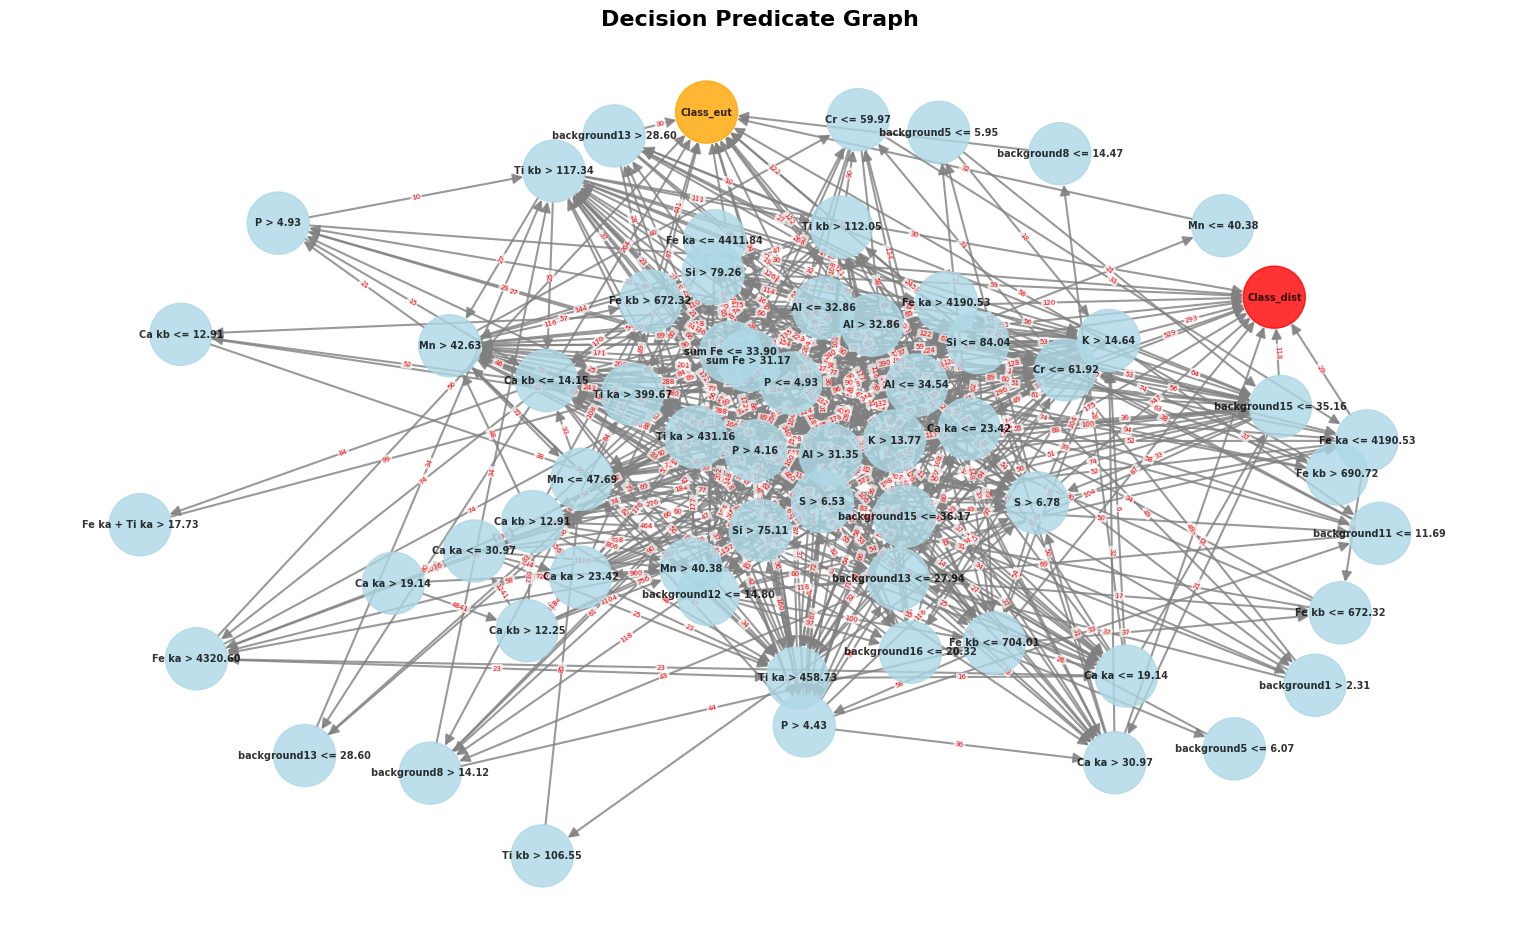

In [20]:
# Plotando o grafo final
import matplotlib.pyplot as plt
import networkx as nx

DG = graphs_by_seed[random_seeds[0]]  # usando o grafo da semente 42 como exemplo

# Layout hierárquico simples
pos = nx.spring_layout(DG, k=10, iterations=100, seed=42)

# Cores dos nós
colors = []
for node in DG.nodes():
    node_type = DG.nodes[node].get('node_type', 'predicate')
    if node_type == 'root_predicate':
        colors.append('green')
    elif node_type == 'terminal':
        colors.append('orange' if DG.nodes[node].get('class_label') == 'eut' else 'red')
    else:
        colors.append('lightblue')

# Preparar labels das arestas (pesos)
edge_labels = {(u, v): f"{DG[u][v]['weight']:.0f}" for u, v in DG.edges()}

# Plotando
plt.figure(figsize=(15, 9))
nx.draw(DG, pos, 
        node_color=colors,
        node_size=2000,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.5,
        alpha=0.8)

# Adicionar labels dos pesos nas arestas
nx.draw_networkx_edge_labels(DG, pos, 
                              edge_labels=edge_labels, 
                              font_size=5, 
                              font_color='red',
                              bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor='white', 
                                       edgecolor='none', 
                                       alpha=0.7))

plt.title('Decision Predicate Graph',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_zones_full = [
('background1', 1.0, 1.33),
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('background2', 1.87, 1.93),
('P', 1.94, 2.10),
('background3', 2.11, 2.19),
('S', 2.20, 2.44),
('background4', 2.45, 2.55),
('Rh L + Ar', 2.56, 3.10),
('background5', 3.11, 3.21),
('K', 3.22, 3.42),
('background6', 3.43, 3.53),
('Ca ka', 3.54, 3.82),
('Ca kb', 3.92, 4.14),
('background8', 4.15, 4.37),
('Ti ka', 4.38, 4.66),
('background9', 4.67, 4.75),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.02),
('background11', 6.03, 6.13),
('Fe ka', 6.14, 6.68),
('background12', 6.69, 6.80),
('Fe kb', 6.81, 7.30),
('background13', 7.31, 7.91),
('Cu', 7.92, 8.20),
('background14', 8.21, 10.69),
('Fe ka + Ti ka', 10.7, 11.14),
('background15', 11.15, 12.55),
('sum Fe' , 12.56, 13.1),
('background16', 13.11, 15.0)
]

In [22]:
vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_zones_full: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip
vip_scores_df

,energy,VIP_Score,Zone
0,3.7,7.506373,Ca ka
1,3.68,7.262794,Ca ka
2,3.72,7.095937,Ca ka
3,3.66,6.373020,Ca ka
4,3.74,5.982461,Ca ka
...,...,...,...
696,1.24,0.014053,background1
697,14.52,0.013660,background16
698,9.06,0.013577,background14
699,14.92,0.011689,background16


In [23]:
# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

,energy,VIP_Score,Zone
0,3.7,7.506373,Ca ka
1,6.44,4.961940,Fe ka
2,5.9,2.235349,Mn
3,1.74,2.160608,Si
4,7.08,1.832155,Fe kb
5,4.54,1.822532,Ti ka
6,4.02,1.717719,Ca kb
7,1.48,1.160853,Al
8,3.3,1.029316,K
9,12.84,0.752731,sum Fe


In [24]:
reg_vet = pd.DataFrame(plsda_results[3].coef_, columns=plsda_results[3].feature_names_in_) # creating a DataFrame with regression coefficients
reg_vet = reg_vet.T
reg_vet.insert(0, 'energy', reg_vet.index) # adding energy column
reg_vet = reg_vet.reset_index(drop=True)
reg_vet.columns = ['energy', 'Reg_coef'] # renaming
reg_vet['Abs_Reg_coef'] = reg_vet['Reg_coef'].abs() # adding absolute value column
reg_vet = reg_vet.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True) # sorting by absolute value

# gerando uma nova coluna em reg_vet com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_reg = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_zones_full: # iterando sobre cada zona espectral (que tem nome, início e fim)
    for i in reg_vet['energy']: # iterando sobre cada valor de energia no reg_vet
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_reg[i] = zone_name
reg_vet['Zone'] = reg_vet['energy'].map(energy_to_zone_reg) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_reg
reg_vet

# vamos filtrar reg_vet para manter apenas as zonas espectrais únicas com maior valor absoluto do coeficiente de regressão
reg_vet_unique_df = reg_vet.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
reg_vet_unique_df = reg_vet_unique_df.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True)
reg_vet_unique_df

,energy,Reg_coef,Abs_Reg_coef,Zone
0,1.74,-0.048703,0.048703,Si
1,5.9,-0.046786,0.046786,Mn
2,3.7,-0.033770,0.033770,Ca ka
3,4.46,0.022996,0.022996,Ti ka
4,6.42,0.013572,0.013572,Fe ka
5,2.02,0.013222,0.013222,P
6,1.48,0.013022,0.013022,Al
7,4,-0.011633,0.011633,Ca kb
8,9.38,0.011608,0.011608,background14
9,3.3,-0.010813,0.010813,K


C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Using 148 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 148/148 [16:51<00:00,  6.84s/it]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28776\3279461856.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



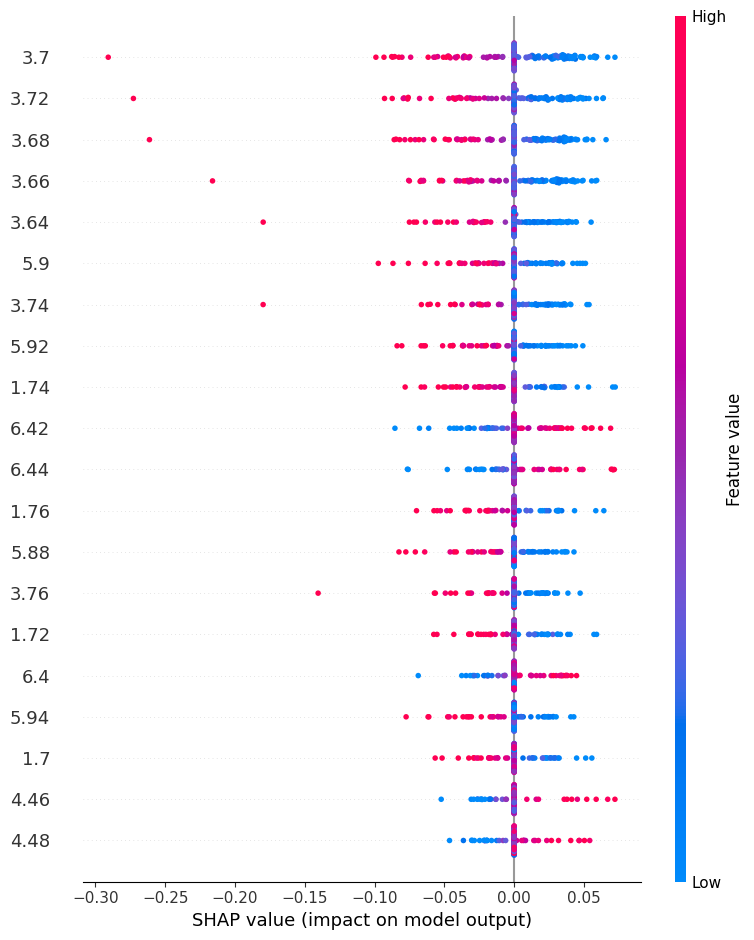

In [26]:
# vamos agora extrair as variaveis mais importantes atraves do método SHAP
import shap

# Para PLSRegression, usamos KernelExplainer porque não há explainer dedicado muito rápido
explainer_pls = shap.KernelExplainer(plsda_results[3].predict, Xcalclass_prep)
shap_values_pls = explainer_pls(Xcalclass_prep)
shap.summary_plot(shap_values_pls, Xcalclass_prep, feature_names=Xpredclass_prep.columns)

In [27]:
shap_global_importance = pd.DataFrame({
    'energy': Xpredclass_prep.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_pls.values).mean(axis=0)}) # tomando a importancia global como a media dos valores absolutos dos valores SHAP para cada feature
shap_global_importance.sort_values(by='Mean_Abs_SHAP', ascending=False, inplace=True)

# vamos gerar uma nova coluna em shap_global_importance com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_shap = {}
for zone_name, start, end in spectral_zones_full:
    for i in shap_global_importance['energy']:
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_shap[i] = zone_name
shap_global_importance['Zone'] = shap_global_importance['energy'].map(energy_to_zone_shap)
shap_global_importance

,energy,Mean_Abs_SHAP,Zone
135,3.7,0.027376,Ca ka
136,3.72,0.023315,Ca ka
134,3.68,0.022607,Ca ka
133,3.66,0.020852,Ca ka
132,3.64,0.014720,Ca ka
...,...,...,...
256,6.12,0.000000,background11
257,6.14,0.000000,Fe ka
258,6.16,0.000000,Fe ka
259,6.18,0.000000,Fe ka


In [28]:
# agora vamos filtrar shap_global_importance para manter apenas as zonas espectrais únicas com maior SHAP score
shap_unique_df = shap_global_importance.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
shap_unique_df = shap_unique_df.sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
shap_unique_df

,energy,Mean_Abs_SHAP,Zone
0,3.7,0.027376,Ca ka
1,5.9,0.012899,Mn
2,1.74,0.011444,Si
3,6.42,0.010995,Fe ka
4,4.46,0.005451,Ti ka
5,7.02,0.000288,Fe kb
6,2.02,0.000048,P
7,3.28,0.000034,K
8,2.44,0.000000,S
9,4.02,0.000000,Ca kb


In [20]:
features_importance = pd.DataFrame({
    'Vip' : vip_scores_unique_df['Zone'].iloc[:15].values,
    'Reg_coef' : reg_vet_unique_df['Zone'].iloc[:15].values,
    'SHAP' : shap_unique_df['Zone'].iloc[:15].values
    })

for seed, lrc_unique_df in lrc_unique_by_seed.items():
    features_importance[f'LRC_Seed_{seed}'] = lrc_unique_df['Zone'].iloc[:15].values
features_importance

NameError: name 'vip_scores_unique_df' is not defined

In [40]:
# utilizando o Rank-Biased Overlap (RBO) para comparar as listas de importância de características tendo o vip como referencia
# com p = 1 é rbo equivalente ao overlap simples (interseção sobre união) sem peso para posições iniciais
# quanto menor o p, mais peso é dado para as posições iniciais da lista (mais relevante para nosso caso)
import rbo

rbo_results = {}
reference_list = features_importance['Vip'].tolist()
methods = ['Reg_coef', 'SHAP'] + [f'LRC_Seed_{seed}' for seed in random_seeds]
for method in methods:
    compare_list = features_importance[method].tolist()
    score = rbo.RankingSimilarity(reference_list, compare_list).rbo(p=0.8, k=15) # o p=0.9 dá mais peso para as posições iniciais, k=10 limita a comparação às top 10 posições
    rbo_results[method] = score
rbo_results = pd.DataFrame(list(rbo_results.items()), columns=['Method', 'RBO_Score'])
rbo_results.insert(0, 'Reference', 'Vip')
rbo_results.sort_values(by='RBO_Score', ascending=False, inplace=True)
rbo_results

,Reference,Method,RBO_Score
1,Vip,SHAP,0.782275
2,Vip,LRC_Seed_0,0.732616
4,Vip,LRC_Seed_128,0.560025
5,Vip,LRC_Seed_256,0.514430
0,Vip,Reg_coef,0.465626
3,Vip,LRC_Seed_42,0.411758


In [31]:
rbo_comparison = pd.DataFrame(columns=['Method_1', 'Method_2', 'RBO_Score'])
methods = features_importance.columns.tolist()
for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        method_1 = methods[i]
        method_2 = methods[j]
        list_1 = features_importance[method_1].tolist()
        list_2 = features_importance[method_2].tolist()
        rbo_score = rbo.RankingSimilarity(list_1, list_2).rbo(p=1.0, k=10)
        rbo_comparison = pd.concat([rbo_comparison, pd.DataFrame({
            'Method_1': [method_1],
            'Method_2': [method_2],
            'RBO_Score': [rbo_score]
        })], ignore_index=True)
rbo_comparison.sort_values(by='RBO_Score', ascending=False, inplace=True)
rbo_comparison

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28776\1137544429.py:10: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,Method_1,Method_2,RBO_Score
18,LRC_Seed_42,LRC_Seed_128,0.929722
19,LRC_Seed_42,LRC_Seed_256,0.905437
20,LRC_Seed_128,LRC_Seed_256,0.871825
16,LRC_Seed_0,LRC_Seed_128,0.852540
1,Vip,SHAP,0.815159
15,LRC_Seed_0,LRC_Seed_42,0.808929
17,LRC_Seed_0,LRC_Seed_256,0.808929
14,SHAP,LRC_Seed_256,0.742540
5,Vip,LRC_Seed_256,0.733651
6,Reg_coef,SHAP,0.715714


In [32]:
# calculando a mutual information relacionando cada variável espectral com a predição do modelo PLS-DA
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
global_mi_scores = mutual_info_regression(Xcalclass_prep, 
                                    plsda_results[5].iloc[:,-1], # using the continuous predictions from LV=3
                                    discrete_features=False,
                                    n_neighbors=100)
global_mi_scores_df = pd.DataFrame(global_mi_scores, index=Xcalclass_prep.columns, columns=['MI Score'])#.sort_values(by='MI Score', ascending=False)
global_mi_scores_df.plot()


In [33]:
plsda_results[4].T.plot() # VIP scores plot

In [34]:
# calculando a covariancia entre cada variável espectral e a predição do modelo PLS-DA
cov_scores = []
y_pred = plsda_results[5].iloc[:,-1].values # using the continuous predictions from LV=3
for col in Xcalclass_prep.columns:
    x_values = Xcalclass_prep[col].values
    covariance = np.cov(x_values, y_pred)[0, 1] # covariance between x and y
    cov_scores.append(covariance)
cov_scores_df = pd.DataFrame(cov_scores, index=Xcalclass_prep.columns, columns=['Covariance'])
cov_scores_df = np.abs(cov_scores_df)
cov_scores_df.plot()

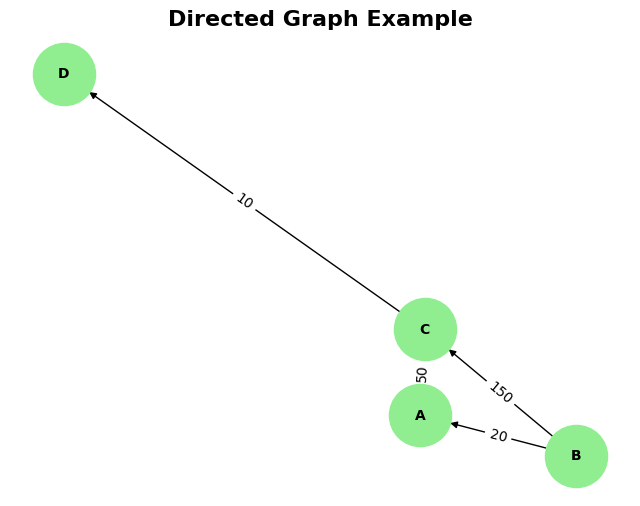

In [164]:
DG = nx.DiGraph()
DG.add_node("A")
DG.add_node("B")
DG.add_node("C")
DG.add_node("D")
DG.add_edge("B", "A", weight=20)
DG.add_edge("B", "C", weight=150)
DG.add_edge("A", "C", weight=50)
DG.add_edge("C", "D", weight=10)
 #plotar o grafo direcionado
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(DG, seed=42)
nx.draw(DG, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold', arrows=True)
edge_labels = nx.get_edge_attributes(DG, 'weight')
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels)
plt.title('Directed Graph Example', fontsize=16, fontweight='bold')
plt.show()